# Grounding Test
This notebook is dedicated to testing the visual grounding capabilities of the C-RADIOv4-SO400M model on egocentric assembly frames.

## Phase 0.1: Model Loading and VRAM Sanity Check
In this section, we initialize the model from local weights, perform a forward pass on a single raw frame, and reshape the output spatial features into a 2D grid.

In [2]:
import torch
from PIL import Image
from transformers import AutoModel, CLIPImageProcessor
from einops import rearrange
import time

print("Loading the model (this might take a few seconds)...")

# 1. Point to the local directory where we downloaded the weights
local_repo = "../models/c_radio_weights"

# 2. Load the processor and the model into VRAM
image_processor = CLIPImageProcessor.from_pretrained(local_repo)
model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)
model.eval().cuda() # Move the model to the GPU

print("Model successfully loaded into VRAM!")

# 3. Load one of your extracted frames
image_path = '../data/extracted_frames/assembly_2_f0003.jpg'
image = Image.open(image_path).convert('RGB')

# 4. Image preprocessing
pixel_values = image_processor(images=image, return_tensors='pt', do_resize=True).pixel_values
pixel_values = pixel_values.cuda()

print(f"Input image tensor shape: {pixel_values.shape}")

# 5. Inference (Memory critical phase)
print("Starting inference...")
start_time = time.time()

# Using torch.no_grad() is vital to prevent allocating memory for training
with torch.no_grad():
    # C-RADIOv4 returns two tensors: a global summary and dense spatial features
    summary, spatial_features = model(pixel_values)

# 6. Reshape the spatial features
# The patch size of C-RADIO is 16. We use einops to convert the 1D tensor back to a 2D grid (B, D, H, W)
patch_size = 16
h = pixel_values.shape[-2] // patch_size
w = pixel_values.shape[-1] // patch_size
spatial_features_2d = rearrange(spatial_features, 'b (h w) d -> b d h w', h=h, w=w)

end_time = time.time()

# 7. Results
print("\n--- TEST SUCCESSFULLY COMPLETED ---")
print(f"Local inference time: {end_time - start_time:.4f} seconds")
print(f"Summary Token shape (Global concept): {summary.shape}")
print(f"Spatial Features shape (Dense 2D grid): {spatial_features_2d.shape}")

Loading the model (this might take a few seconds)...


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

Model successfully loaded into VRAM!
Input image tensor shape: torch.Size([1, 3, 512, 512])
Starting inference...

--- TEST SUCCESSFULLY COMPLETED ---
Local inference time: 0.0182 seconds
Summary Token shape (Global concept): torch.Size([1, 2304])
Spatial Features shape (Dense 2D grid): torch.Size([1, 1152, 32, 32])


## Phase 0.1.5: Unsupervised Semantic Feature Visualization (PCA)

This section reduces the dense 1152-dimensional spatial features using PCA and plots them as an RGB semantic map alongside the original image. 

Running PCA to visualize semantic features...


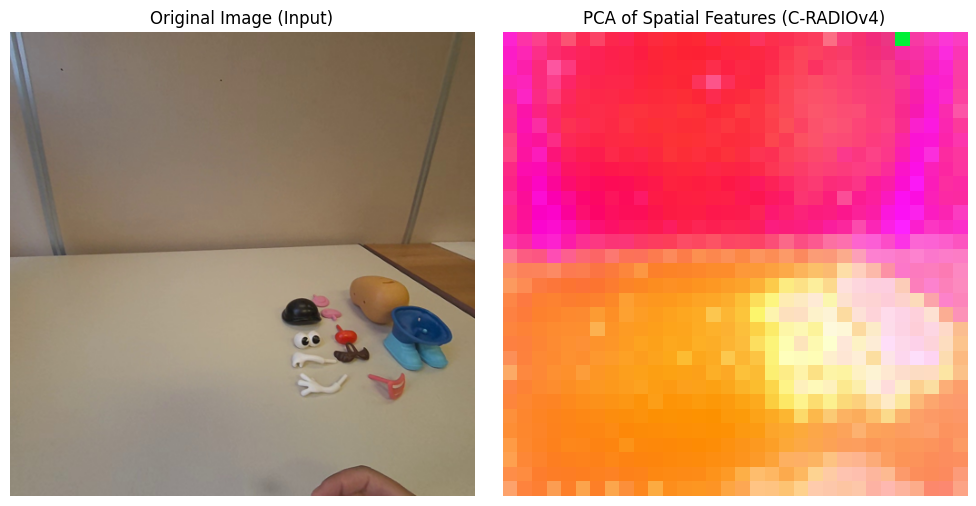

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("Running PCA to visualize semantic features...")

# 1. Remove the batch dimension from the 2D features [1, 1152, 32, 32] -> [1152, 32, 32]
features_np = spatial_features_2d[0].cpu().numpy()

# 2. Flatten spatial dimensions for PCA -> [1024, 1152] (1024 pixels, 1152 features)
features_flat = features_np.reshape(features_np.shape[0], -1).T 

# 3. Reduce from 1152 dimensions down to 3 dimensions (RGB)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(features_flat)

# 4. Normalize values between 0 and 1 to plot them as RGB colors
pca_features_norm = (pca_features - pca_features.min(0)) / (pca_features.max(0) - pca_features.min(0))

# 5. Reshape back to the 32x32 grid -> [32, 32, 3]
pca_img = pca_features_norm.reshape(32, 32, 3)

# 6. Plot the results!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image (resized for comparison)
axes[0].imshow(image.resize((512, 512)))
axes[0].set_title("Original Image (Input)")
axes[0].axis('off')

# PCA map of the features
axes[1].imshow(pca_img)
axes[1].set_title("PCA of Spatial Features (C-RADIOv4)")
axes[1].axis('off')

plt.tight_layout()
plt.show()